In [25]:
import pandas as pd

# **PREDICT**

In [26]:
# from joblib import load

# KNN = load('D:\Garpit\Kerja\Kerja Beneran\Zona 11 DB LPO\Garpit Area\Aug 07 2025\Rate Prediction\SKW-35\knn_model_v.joblib')

In [27]:
# from joblib import load

# KNN = load(r"D:\Garpit\Kerja\Kerja Beneran\Zona 11 DB LPO\Garpit Area\Aug 22 2025\Rate Prediction\Dari Log dan Prod\xgboost_r.joblib")

In [28]:
from joblib import load

KNN = load(r"D:\Garpit\Kerja\Kerja Beneran\Zona 11 DB LPO\Garpit Area\Sept 4 2025\Dari Log dan Prod\Semua Param\knn_model_r.joblib")

In [29]:
df = pd.read_csv('SKW Final.csv')

print("DataFrame Head:")
display(df.head())

print("\nDataFrame Info:")
display(df.info())

DataFrame Head:


,Location,UWI,Reading Time,Average Amps (A) (Raw),Drive Frequency (Hz) (Raw),Intake Pressure (psi) (Raw),Discharge Pressure (psi) (Raw),Intake Temperature (F) (Raw),Motor Temperature (F) (Raw),Vibration (gravit) (Raw)
0,SKW-18,SKW-18,2025-06-01 11:54:26,0.0,0.00,NaN,NaN,NaN,NaN,NaN
1,SKW-18,SKW-18,2025-06-01 12:00:00,0.0,0.00,NaN,NaN,NaN,NaN,NaN
2,SKW-18,SKW-18,2025-06-03 00:10:00,0.1,52.34,NaN,NaN,NaN,NaN,NaN
3,SKW-18,SKW-18,2025-06-03 00:28:58,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,SKW-18,SKW-18,2025-06-03 00:40:00,0.0,0.00,NaN,NaN,NaN,NaN,NaN



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9432 entries, 0 to 9431
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Location                        9432 non-null   object 
 1   UWI                             9432 non-null   object 
 2   Reading Time                    9432 non-null   object 
 3   Average Amps (A) (Raw)          9302 non-null   float64
 4   Drive Frequency (Hz) (Raw)      8808 non-null   float64
 5   Intake Pressure (psi) (Raw)     8565 non-null   float64
 6   Discharge Pressure (psi) (Raw)  8566 non-null   float64
 7   Intake Temperature (F) (Raw)    8550 non-null   float64
 8   Motor Temperature (F) (Raw)     8554 non-null   float64
 9   Vibration (gravit) (Raw)        8551 non-null   float64
dtypes: float64(7), object(3)
memory usage: 737.0+ KB


None

In [30]:
df.dropna(inplace=True)

In [31]:
df_clear = df.drop(df.columns[[0,1,2,6]], axis=1)

In [32]:
df_clear

,Average Amps (A) (Raw),Drive Frequency (Hz) (Raw),Intake Pressure (psi) (Raw),Intake Temperature (F) (Raw),Motor Temperature (F) (Raw),Vibration (gravit) (Raw)
234,58.2,45.0,9425.0,2.546000e+03,2.976000e+03,60.0
235,58.1,45.0,9447.0,2.547000e+03,2.977000e+03,63.0
237,58.3,45.0,9431.0,2.547000e+03,2.975000e+03,64.0
238,58.1,45.0,9411.0,2.548000e+03,2.976000e+03,60.0
239,58.2,45.0,9388.0,2.547000e+03,2.976000e+03,60.0
...,...,...,...,...,...,...
9427,56.6,45.0,0.0,-4.000000e-09,-4.000000e-09,0.0
9428,56.9,45.0,0.0,-4.000000e-09,-4.000000e-09,0.0
9429,56.8,45.0,0.0,-4.000000e-09,-4.000000e-09,0.0
9430,56.8,45.0,0.0,-4.000000e-09,-4.000000e-09,0.0


In [33]:
# # Buat salinan daftar nama kolom
# cols1 = df_clear.columns.tolist()

# cols1[0] = 'A'
# cols1[1] = 'IP'
# cols1[2] = 'IT'   
# cols1[3] = 'MT'   
# # cols1[4] = 'V'     

# # Terapkan kembali ke dataframe
# df_clear.columns = cols1

In [34]:
df_clear.head()

,Average Amps (A) (Raw),Drive Frequency (Hz) (Raw),Intake Pressure (psi) (Raw),Intake Temperature (F) (Raw),Motor Temperature (F) (Raw),Vibration (gravit) (Raw)
234,58.2,45.0,9425.0,2546.0,2976.0,60.0
235,58.1,45.0,9447.0,2547.0,2977.0,63.0
237,58.3,45.0,9431.0,2547.0,2975.0,64.0
238,58.1,45.0,9411.0,2548.0,2976.0,60.0
239,58.2,45.0,9388.0,2547.0,2976.0,60.0


In [35]:
result = KNN.predict(df_clear)

In [36]:
df_result = df_clear

In [37]:
df['Virtual Rate (BFPD) (Raw)'] = result

In [38]:
df.head()

,Location,UWI,Reading Time,Average Amps (A) (Raw),Drive Frequency (Hz) (Raw),Intake Pressure (psi) (Raw),Discharge Pressure (psi) (Raw),Intake Temperature (F) (Raw),Motor Temperature (F) (Raw),Vibration (gravit) (Raw),Virtual Rate (BFPD) (Raw)
234,SKW-18,SKW-18,2025-06-04 12:14:14,58.2,45.0,9425.0,14448.0,2546.0,2976.0,60.0,3373.339568
235,SKW-18,SKW-18,2025-06-04 12:20:00,58.1,45.0,9447.0,14431.0,2547.0,2977.0,63.0,3370.767219
237,SKW-18,SKW-18,2025-06-04 12:30:00,58.3,45.0,9431.0,14421.0,2547.0,2975.0,64.0,3371.662607
238,SKW-18,SKW-18,2025-06-04 12:40:00,58.1,45.0,9411.0,14446.0,2548.0,2976.0,60.0,3372.311640
239,SKW-18,SKW-18,2025-06-04 12:50:00,58.2,45.0,9388.0,14291.0,2547.0,2976.0,60.0,3373.479497


In [39]:
df['Virtual Rate (BFPD) (Raw)'] = df.apply(
    lambda row: 0 if (row['Average Amps (A) (Raw)'] == 0 and row['Drive Frequency (Hz) (Raw)'] == 0)
    else row['Virtual Rate (BFPD) (Raw)'],
    axis=1
)

In [40]:
df.to_csv('SKW_final_w_Pd.csv', index=False)

# **COMPARING**

## Compare 2

In [41]:
import os
# Ambil nilai unik dari kolom Location
loc = df['Location'].iloc[0]   # atau df['Location'].unique()[0]

# Buat path lengkap
base_path = r"D:\Garpit\Kerja\Kerja Beneran\Zona 11 DB LPO\Garpit Area\Sept 4 2025\Dari Log dan Prod"
filename = f"{loc}.csv"
file_path = os.path.join(base_path, filename)

# Baca CSV
df_raw = pd.read_csv(file_path)

In [42]:
df_raw.head()

,Reading Time,Average Amps (A) (Raw),Drive Frequency (Hz) (Raw),Intake Pressure (psi) (Raw),Discharge Pressure (psi) (Raw),Intake Temperature (F) (Raw),Motor Temperature (F) (Raw),Vibration (gravit) (Raw),Virtual Rate (BFPD) (Raw)
0,2025-06-01,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
1,2025-06-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
2,2025-06-03,53.111565,41.974406,NaN,NaN,NaN,NaN,NaN,2475.380240
3,2025-06-04,58.231333,45.000000,9325.500,13658.376471,2551.162162,2922.810127,57.260274,3410.531328
4,2025-06-05,58.223448,45.000000,9149.725,14314.550000,2558.062500,2986.562500,57.562500,3410.531328


In [43]:
df_raw = df_raw.drop(df_raw.columns[[1,2,3,4,5,6,7]], axis=1)

In [44]:
df_test = df_raw

In [45]:
cols = df_test.columns.tolist()

# Hitung jumlah kolom NaN yang ditemukan
nan_count = 0

# Buat list baru dengan nama kolom yang diperbarui
new_cols = []

for col in cols:
    if pd.isna(col):
        nan_count += 1
        if nan_count == 1:
            new_cols.append('Date')
        elif nan_count == 2:
            new_cols.append('R')
        else:
            new_cols.append(col)  # biarkan tetap NaN kalau lebih dari dua
    else:
        new_cols.append(col)

# Ganti nama kolom di DataFrame
df_test.columns = new_cols

In [46]:
# Buat salinan daftar nama kolom
cols = df_test.columns.tolist()

cols[1] = 'R'

# Terapkan kembali ke dataframe
df_test.columns = cols

In [47]:
df_test = df_test[['Reading Time','R']]
df_test = df_test.dropna()

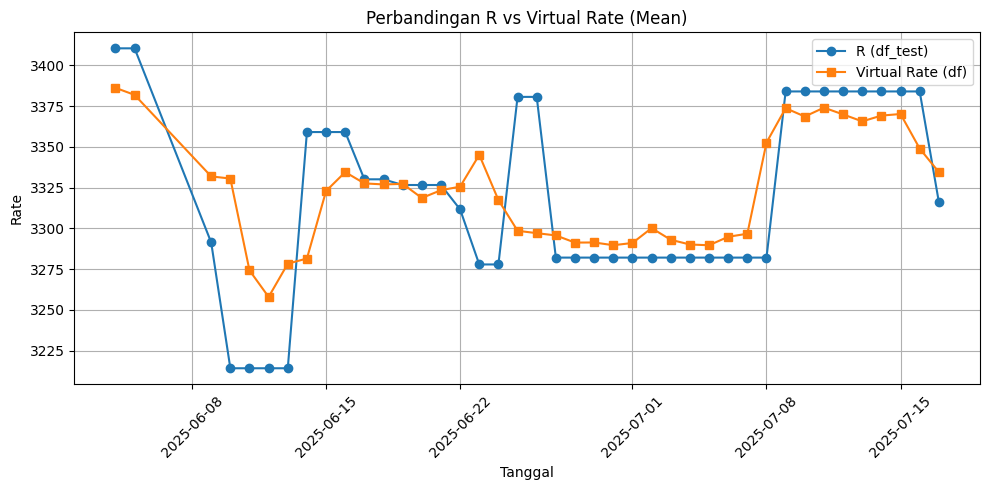

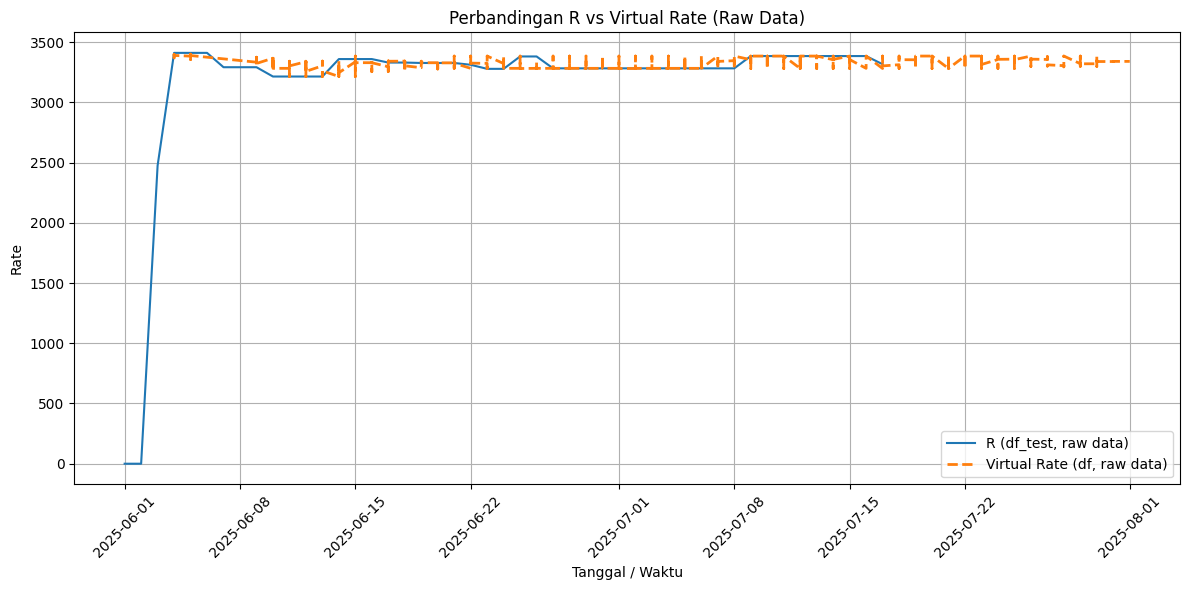

In [48]:
import matplotlib.pyplot as plt

# Pastikan datetime
df_test['Reading Time'] = pd.to_datetime(df_test['Reading Time'])
df['Reading Time'] = pd.to_datetime(df['Reading Time'])

# Ambil tanggal saja
df['Reading Time'] = df['Reading Time'].dt.date
df_test['Reading Time'] = df_test['Reading Time'].dt.date

# Hitung rata-rata Virtual Rate per tanggal
df_daily = df.groupby('Reading Time', as_index=False)['Virtual Rate (BFPD) (Raw)'].mean()

# Merge
merged = pd.merge(df_test, df_daily, on='Reading Time', how='inner')

# Pastikan semua jadi array 1D
dates = pd.to_datetime(merged['Reading Time']).to_numpy()
r_values = merged['R'].astype(float).to_numpy()
vr_values = merged['Virtual Rate (BFPD) (Raw)'].astype(float).to_numpy()

# Plot
plt.figure(figsize=(10, 5))
plt.plot(dates, r_values, marker='o', label='R (df_test)')
plt.plot(dates, vr_values, marker='s', label='Virtual Rate (df)')

plt.title('Perbandingan R vs Virtual Rate (Mean)')
plt.xlabel('Tanggal')
plt.ylabel('Rate')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Pastikan datetime
df_test['Reading Time'] = pd.to_datetime(df_test['Reading Time'])
df['Reading Time'] = pd.to_datetime(df['Reading Time'])

# Siapkan array df_test
dates_test = df_test['Reading Time'].to_numpy()
r_values = df_test['R'].astype(float).to_numpy()

# Siapkan array df
dates_df = df['Reading Time'].to_numpy()
vr_values = df['Virtual Rate (BFPD) (Raw)'].astype(float).to_numpy()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(dates_test, r_values, linestyle='-', label='R (df_test, raw data)')
plt.plot(dates_df, vr_values, linestyle='--', label='Virtual Rate (df, raw data)', linewidth=2)

plt.title('Perbandingan R vs Virtual Rate (Raw Data)')
plt.xlabel('Tanggal / Waktu')
plt.ylabel('Rate')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()